In [ ]:
# autoload all the imports
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import argparse
import torch
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi

sys.path.append('../../NORMA/process/')
from process_data import create_sequences

sys.path.append('../../NORMA/model/')

from data import *
from utils import *
from evaluate import *
from model import *

sys.path.append('/n/data1/hms/dbmi/manrai/aashna/NORMA/scripts/')
from plots import *

sys.path.append('/n/data1/hms/dbmi/manrai/aashna/NORMA/baselines/')
from setpoints import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_DIR = '../../NORMA/data/processed/'
LOG_DIR = '../../NORMA/model/logs/'
DATA_PATH = 'merged_lab_data.csv'

FILE_PATH = os.path.join(DATA_DIR, DATA_PATH)
df = pd.read_csv(FILE_PATH)

In [2]:
def sample_seq(df, num_samples=1, pid=None, data_dir=DATA_DIR, csv_name=DATA_PATH):
    if pid is None:
        pids = df['subject_id'].sample(num_samples).values
    else:
        pids = [pid]
    return df.query('subject_id in @pids')

def pred(model, sample, normal=False):
    seq = create_sequences(sample, quiet=True)[0]
    batch = TimeSeriesDataset([seq])[0]
    batch = collate_fn([batch])
    batch = to_device_batch(batch, device)
    if normal:
        batch['s_next'] = torch.ones_like(batch['s_next'])
    else:
        batch['s_next'] = torch.zeros_like(batch['s_next'])
        
    model.eval()
    with torch.no_grad():
        mu, log_var = model(batch['x_h'], batch['s_h'], batch['t_h'], batch['sex'],
                    batch['cid'], batch['s_next'], batch['t_next'], batch['pad_mask'])
        mu = float(mu.cpu().numpy().squeeze())
        log_var = float(log_var.cpu().numpy().squeeze())
        var = np.exp(log_var)
        std = np.sqrt(var)
    return seq, mu, std

def pop_interval(code, sex):
    sex = 'F' if sex == 1 else 'M'
    low, high, _ = REFERENCE_INTERVALS[code][sex]
    std = (high - low) / 4
    mu = (low + high) / 2
    return mu, std

def _row(pid, run_id, source, code, mu, std):
    return {
        "PID": pid,
        "Run ID": run_id,
        "Source": source,
        "Code": code,
        "Mean": float(mu),
        "STD": float(std),
    }

def _build_models(LOG_DIR, run_ids, device):
    out = []
    for run_id in run_ids:
        ckpt, hparams = load_checkpoint(LOG_DIR, run_id, best=True, device=device, quiet=True)
        model = create_model(hparams, 34, ckpt).to(device)
        out.append({"run_id": run_id, "source": hparams.train.upper(), "model": model})
    return out

def predict_intervals(seqs, run_ids, LOG_DIR, device, add_baselines=False):
    rows = []
    models = _build_models(LOG_DIR, run_ids, device)

    for code, seq in seqs.items():
        for i, pid in enumerate(seq['subject_id'].unique()):
            seq_sub = seq.query('subject_id == @pid')
            for m in models:
                seq_, mu, std = pred(m["model"], seq_sub, normal=False)
                rows.append(_row(f'{pid}', m["run_id"], m["source"], code, mu, std))

                seq_, mu, std = pred(m["model"], seq_sub, normal=True)
                rows.append(_row(f'{pid}', f'{m["run_id"]}_N', m["source"], code, mu, std))       
                
        if add_baselines:
            # mu, var = calculate_guassians(seq)  
            # std = np.sqrt(var)*2
            # rows.append(_row("Personalized", "-", code, mu, std))
            
            sex = seq["sex"].iloc[0]
            mu, std = pop_interval(code, sex)
            std = std*2
            rows.append(_row(f'{pid}', "Population", '-', code, mu, std))

    df = pd.DataFrame(rows)
    return df

def _gaussian_pdf(y, mu, sigma):
    s = max(float(sigma), 1e-6)
    z = (y - float(mu)) / s
    return np.exp(-0.5 * z * z) / (s * sqrt(2 * pi))

def plot_sequence_and_intervals(code, seq, df):
    
    y = seq["numeric_value"].to_numpy()
    x = seq["time_delta"].to_numpy()

    fig, axes = plt.subplots(
        nrows=1, ncols=2, figsize=(10, 1.2), width_ratios=[3.3, 1], dpi=300, gridspec_kw={'wspace': 0.02}
    )
    ax, ax_density = axes
    ax.plot(x, y, marker="o", color="black", linewidth=1.1, label=str(code))
    
    sub = df[df["Code"] == code]
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (_, r) in enumerate(sub.iterrows()):
        mu, std = float(r["Mean"]), float(r["STD"])
        c = colors[i % len(colors)]
        if r["Run ID"] == "Population":
            ax.hlines(mu - std, x.min(), x.max(), linestyles=(0, (2, 2)), color=c, linewidth=1.1, label="Population")
            ax.hlines(mu + std, x.min(), x.max(), linestyles=(0, (2, 2)), color=c, linewidth=1.1)
        else:
            ax.axhspan(mu - std, mu + std, alpha=0.18, color=c, label=f"{r['Run ID'].title()}")
            
    ax.set_xlabel("Days")
    ax.set_ylabel(f"{code}")
    ax.set_xlim(x.min(), x.max())

    lows = [y.min()] + list((sub["Mean"] - 2*sub["STD"]).to_numpy())
    highs = [y.max()] + list((sub["Mean"] + 2*sub["STD"]).to_numpy())
    y_lo, y_hi = float(np.min(lows)), float(np.max(highs))
    y_grid = np.linspace(y_lo, y_hi, 500)

    max_peak = 0.0
    pdfs = []
    for _, r in sub.iterrows():
        mu, std = float(r["Mean"]), float(r["STD"])
        if r["Run ID"] != "Population" or "Personalized":
            std = std / 2
        pdf = _gaussian_pdf(y_grid, mu, std)
        pdfs.append(pdf)
        max_peak = max(max_peak, pdf.max())

    ax_density.set_ylim(ax.get_ylim())
    ax_density.yaxis.set_visible(False)
    ax_density.xaxis.set_visible(False)
    ax_density.set_frame_on(False)

    total_width = 0.9
    num_pdfs = len(pdfs)
    density_offset = 0.0
    total_span = total_width * (num_pdfs - 1)
    left_starts = np.linspace(0, total_span, num_pdfs)
  
    height_scale = 1.22
    y_mid = (y_lo + y_hi) / 2
    prev_right = 0.0
    for i, ((_, r), pdf) in enumerate(zip(sub.iterrows(), pdfs)):
        if r["Run ID"] == "Population":
            continue
        c = colors[i % len(colors)]
        scaled = (pdf / max_peak) * total_width
        scaled_y_grid = (y_grid - y_mid) * height_scale + y_mid
        left = prev_right + 0.1
        ax_density.fill_betweenx(scaled_y_grid, left, left + scaled, alpha=0.30, color=c)
        ax_density.plot(left + scaled, scaled_y_grid, linewidth=1, color=c, label=f"{r['Run ID'].title()}")

    handles, labels = [], []
    seen = set()
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in seen:
            handles.append(h)
            labels.append(l)
            seen.add(l)

    fig.legend(handles, labels, frameon=False, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.2))
    fig.tight_layout(rect=[0, 0, 1, 1])
    plt.show()



In [3]:
seqs = {}
for test_name, group in df.groupby('test_name'):
    if test_name not in ['PLT']:
        continue
    seqs[test_name] = sample_seq(group, num_samples=10)
    

,PID,Run ID,Source,Code,Mean,STD
0,15230748,87345aff,COMBINED,PLT,114.353188,33.877646
1,15230748,87345aff_N,COMBINED,PLT,196.753311,38.470900
2,15657398,87345aff,COMBINED,PLT,242.431732,259.743790
3,15657398,87345aff_N,COMBINED,PLT,245.693192,65.360138
4,16465340,87345aff,COMBINED,PLT,146.887589,75.116361
5,16465340,87345aff_N,COMBINED,PLT,237.987045,50.116343
6,17175688,87345aff,COMBINED,PLT,234.932251,196.449805
7,17175688,87345aff_N,COMBINED,PLT,245.581848,53.923865
8,17333368,87345aff,COMBINED,PLT,241.469040,246.318794
9,17333368,87345aff_N,COMBINED,PLT,245.684937,58.172746


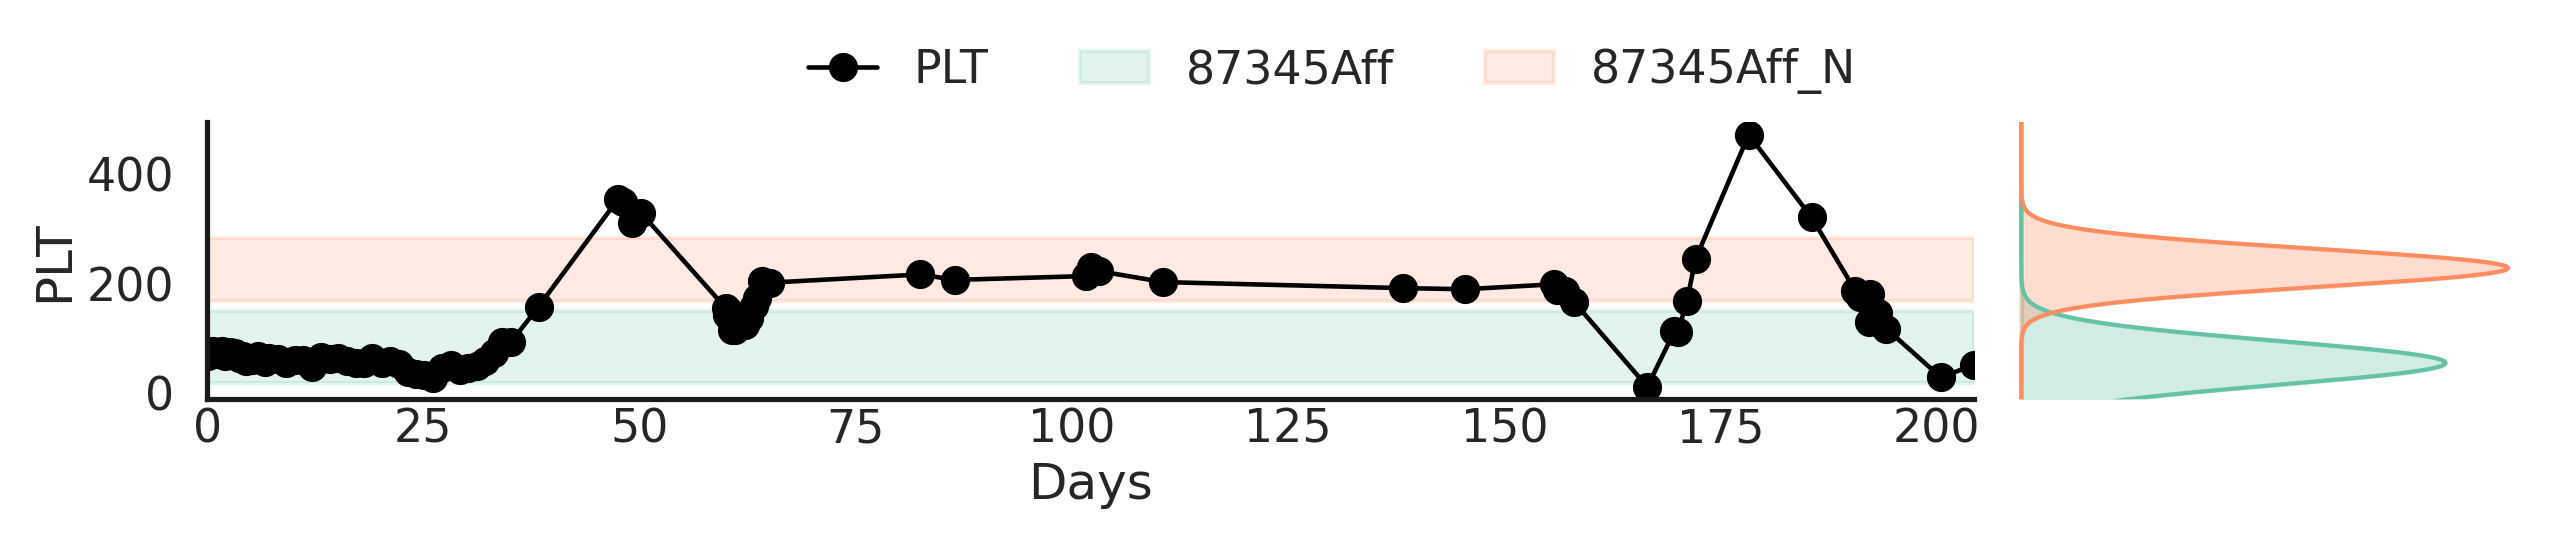

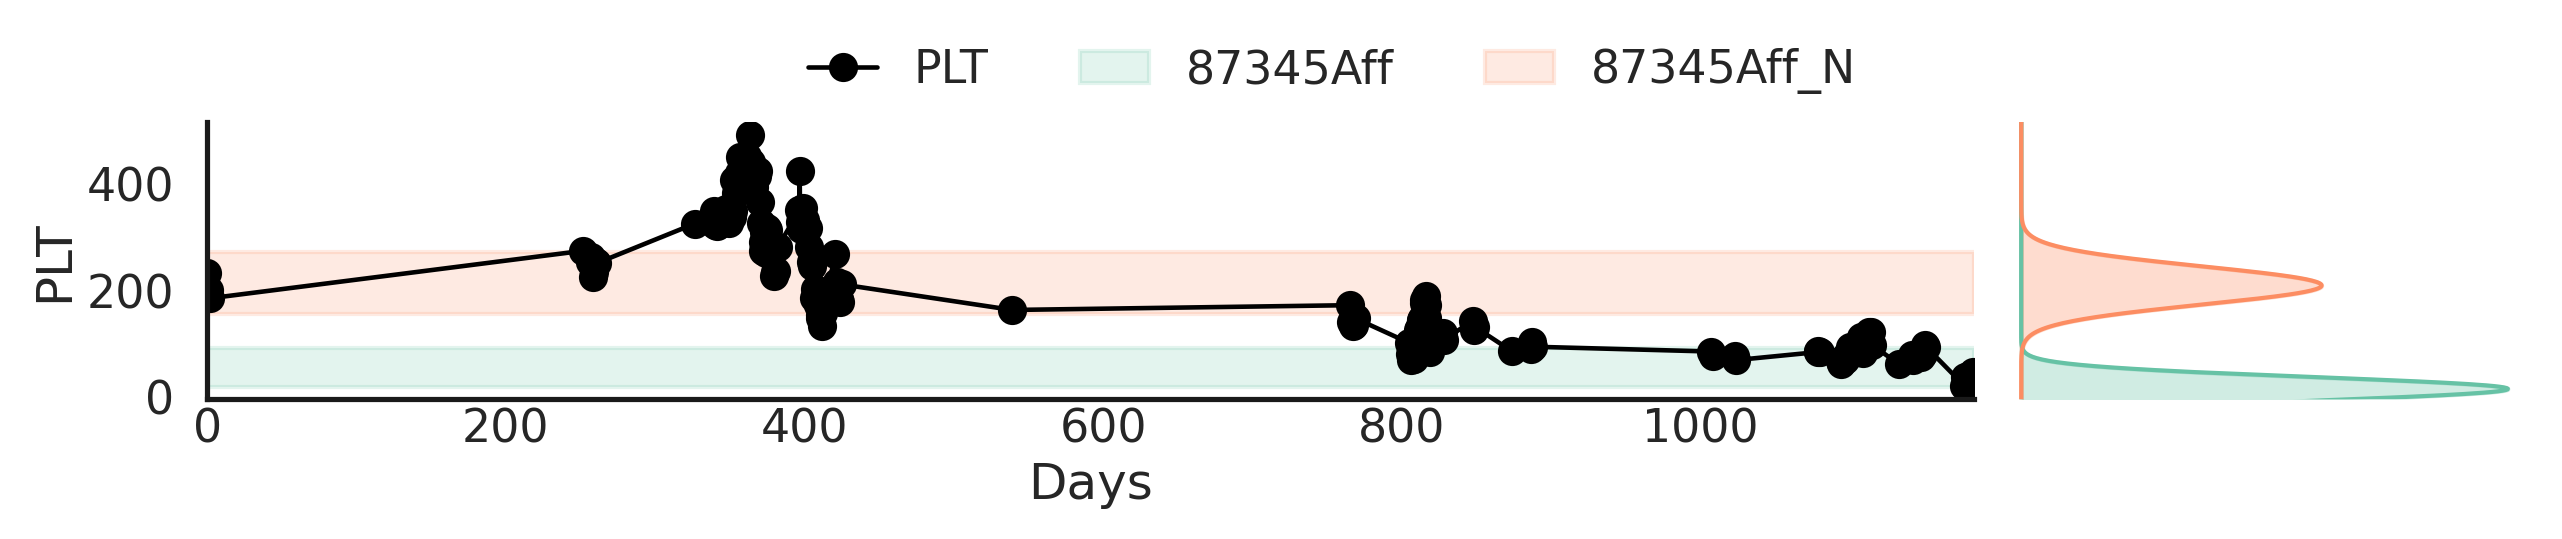

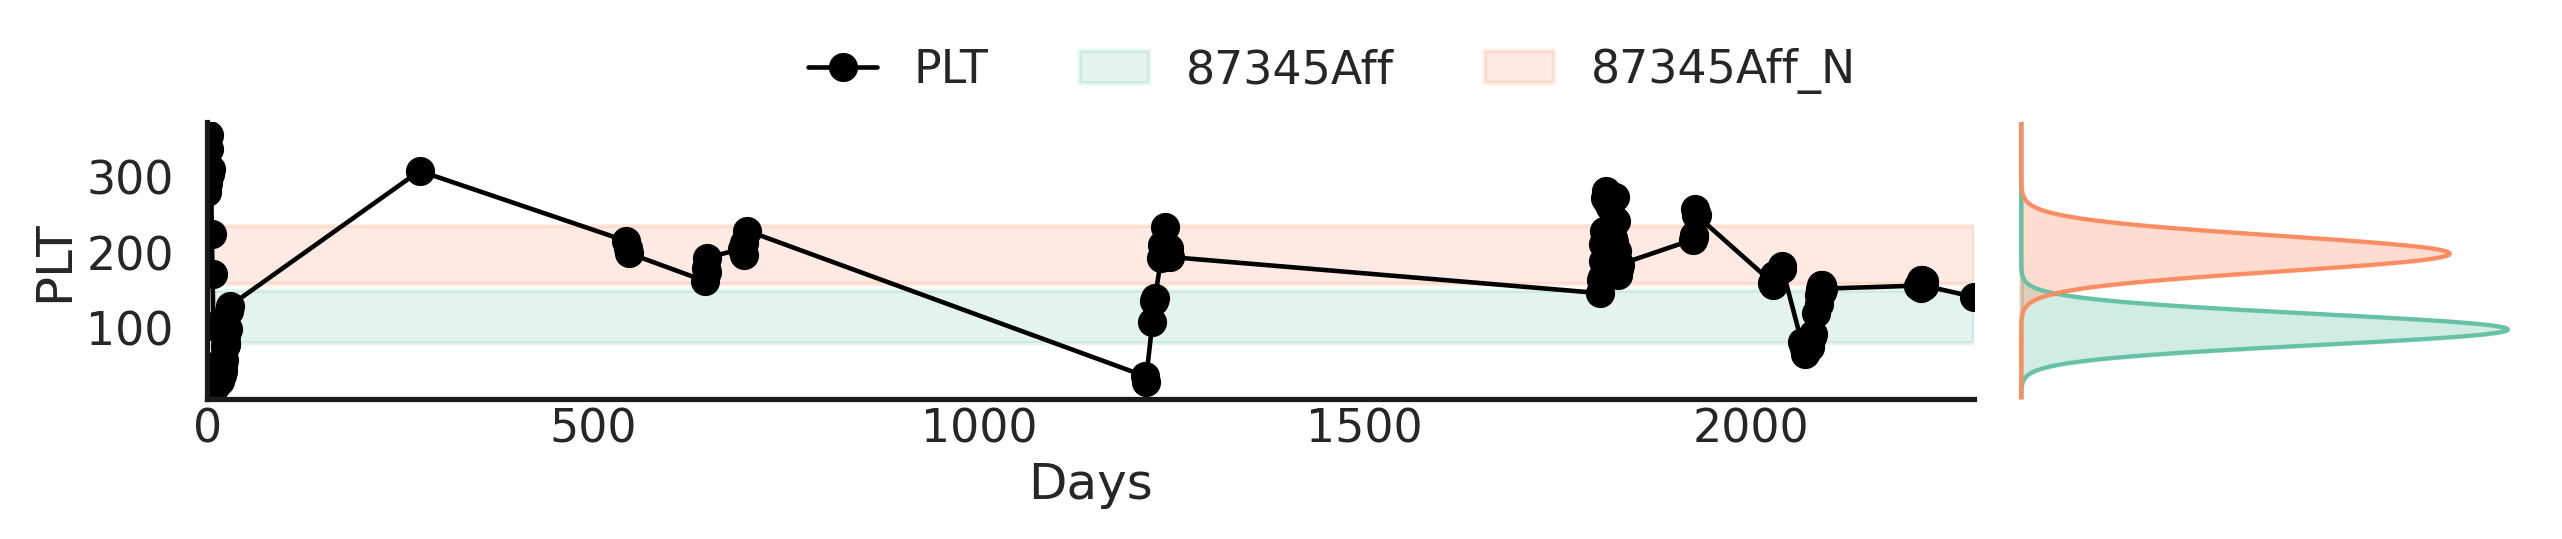

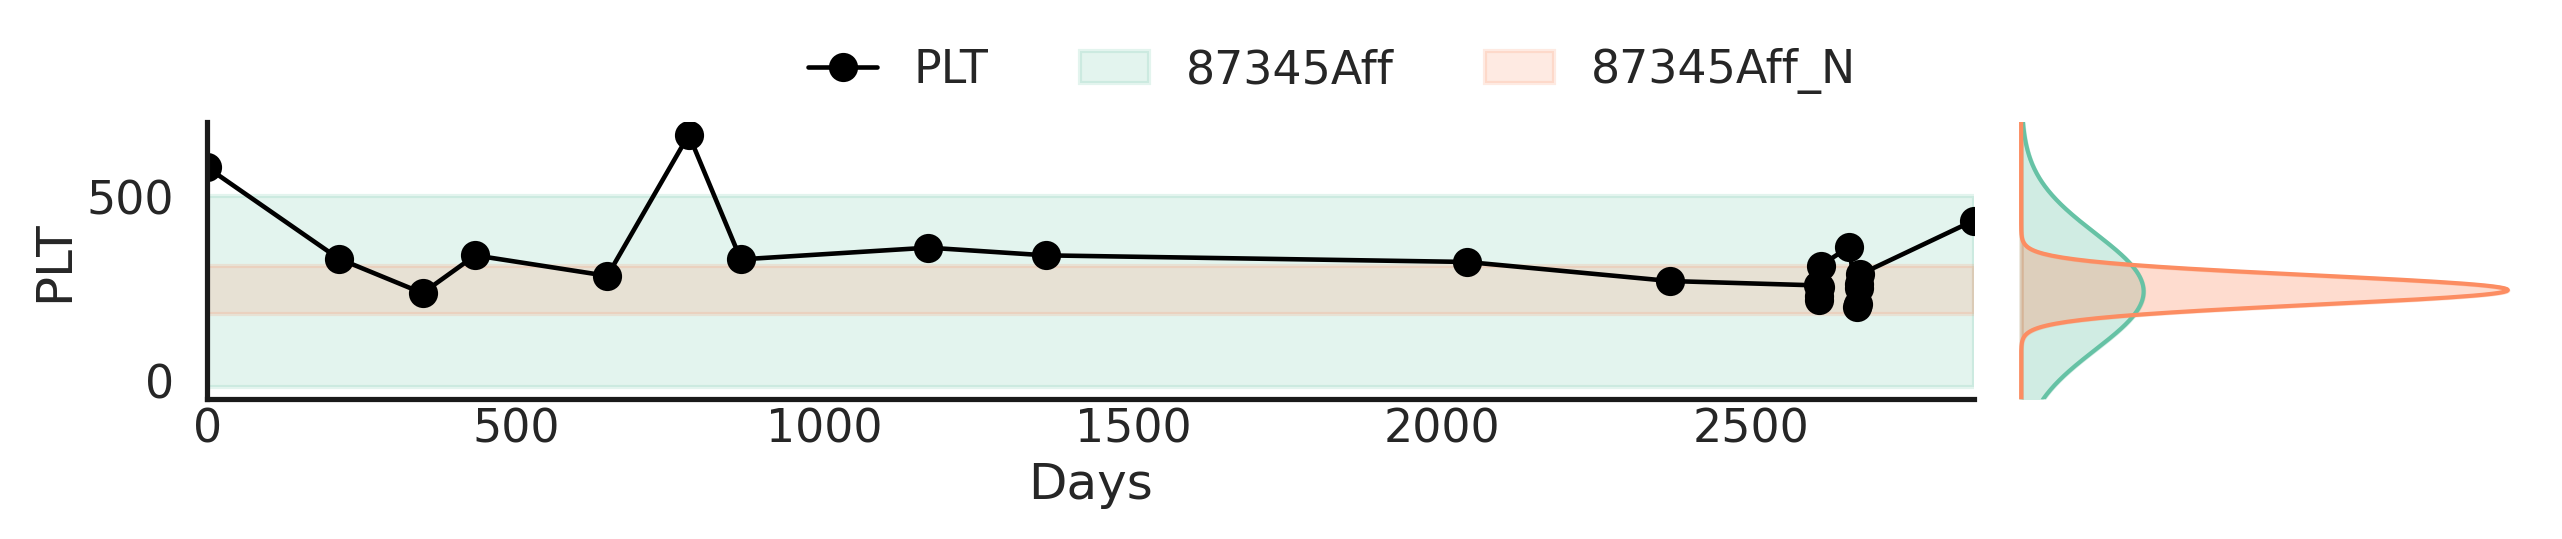

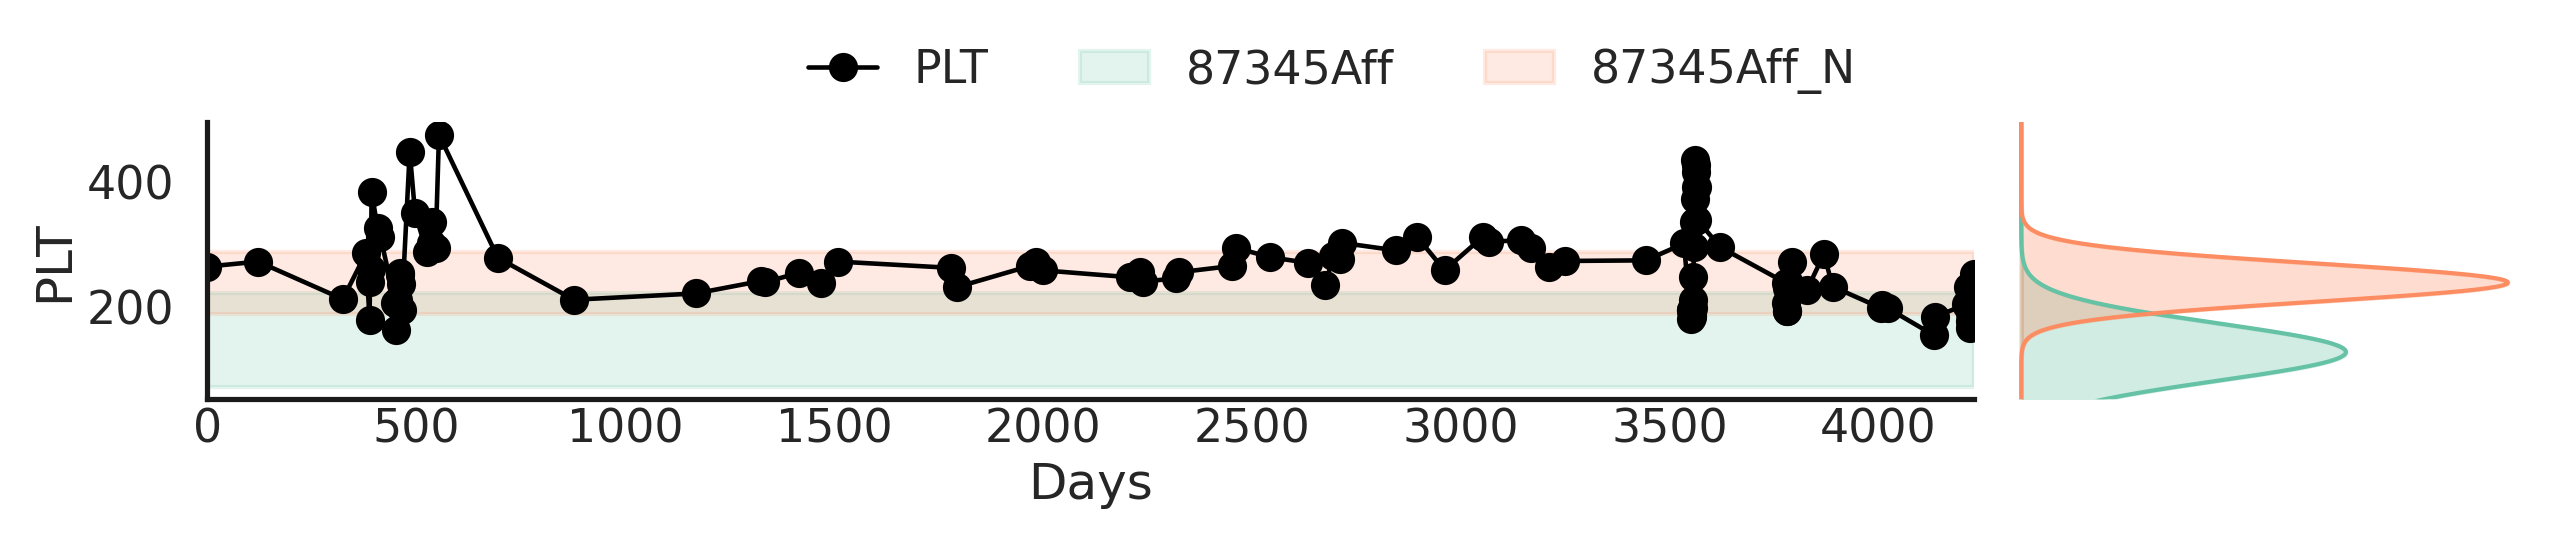

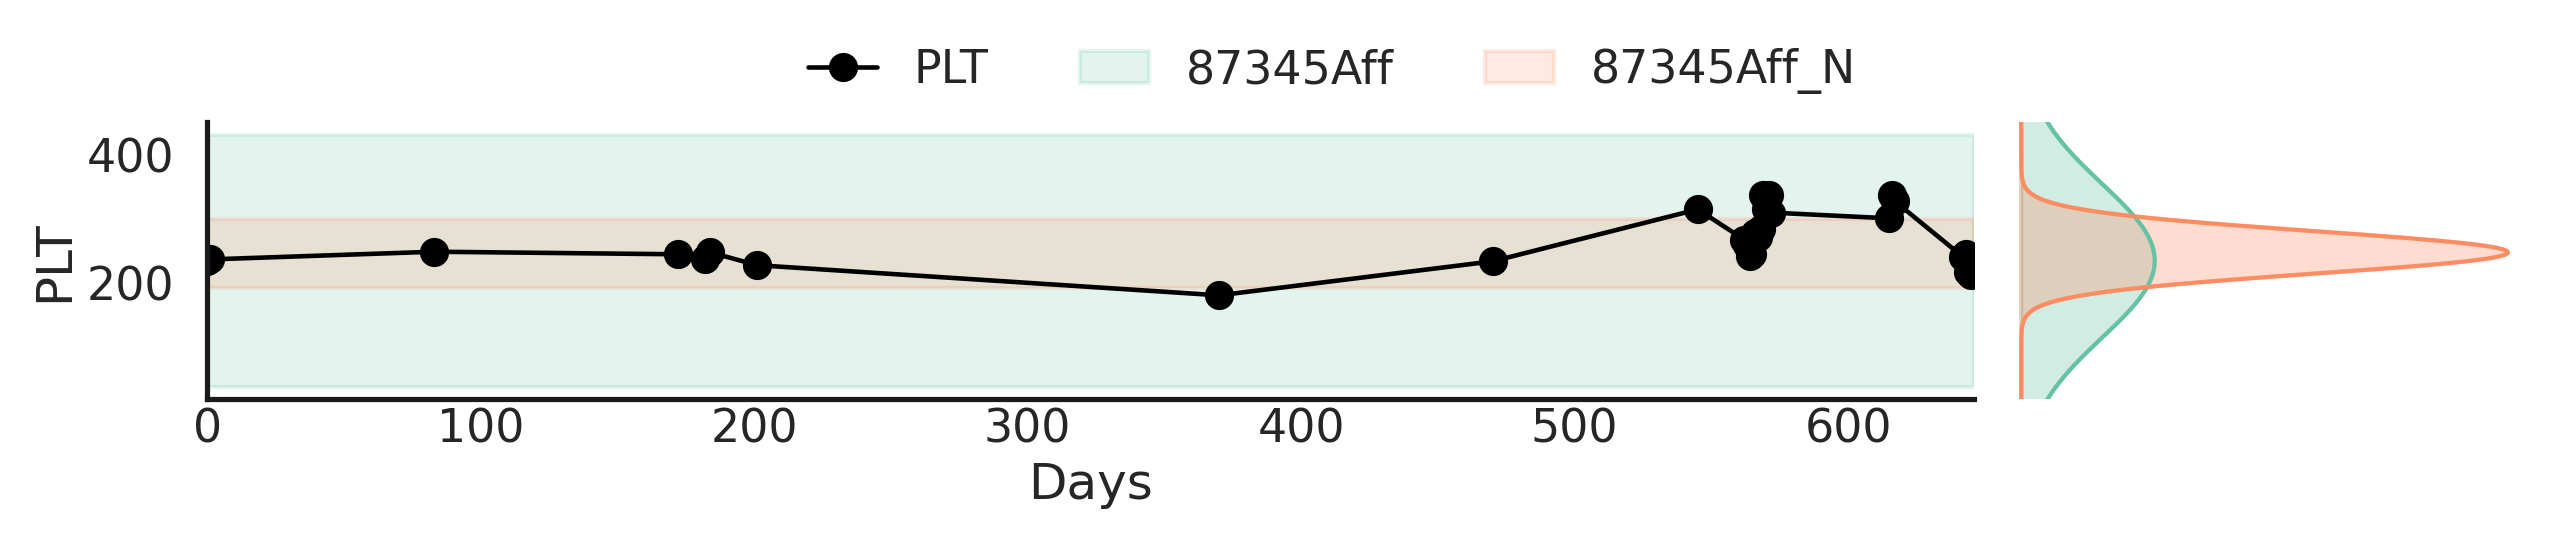

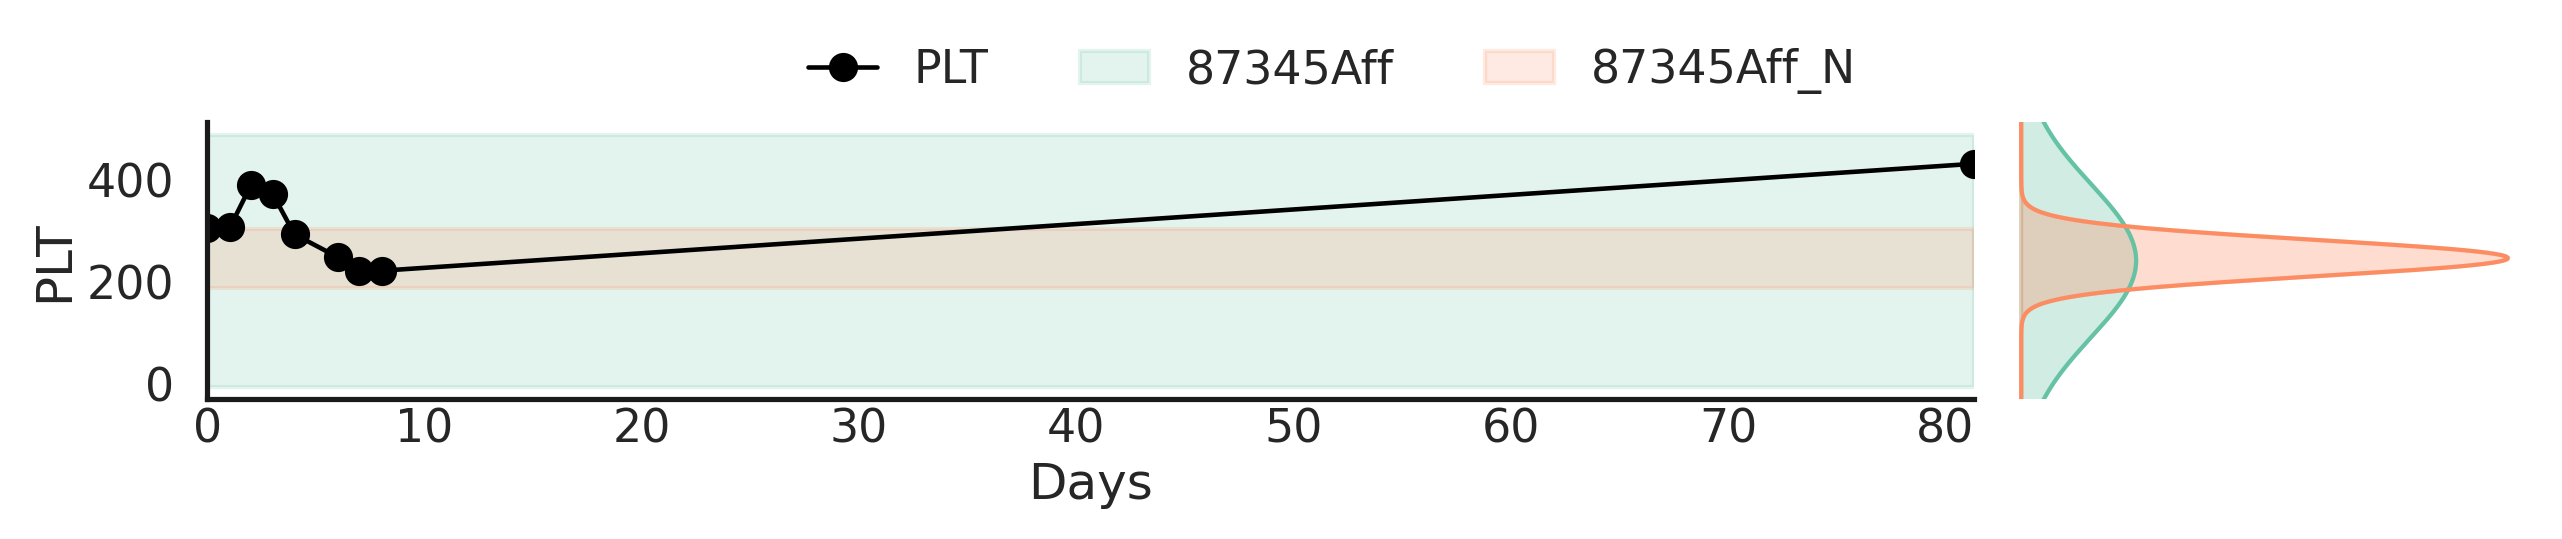

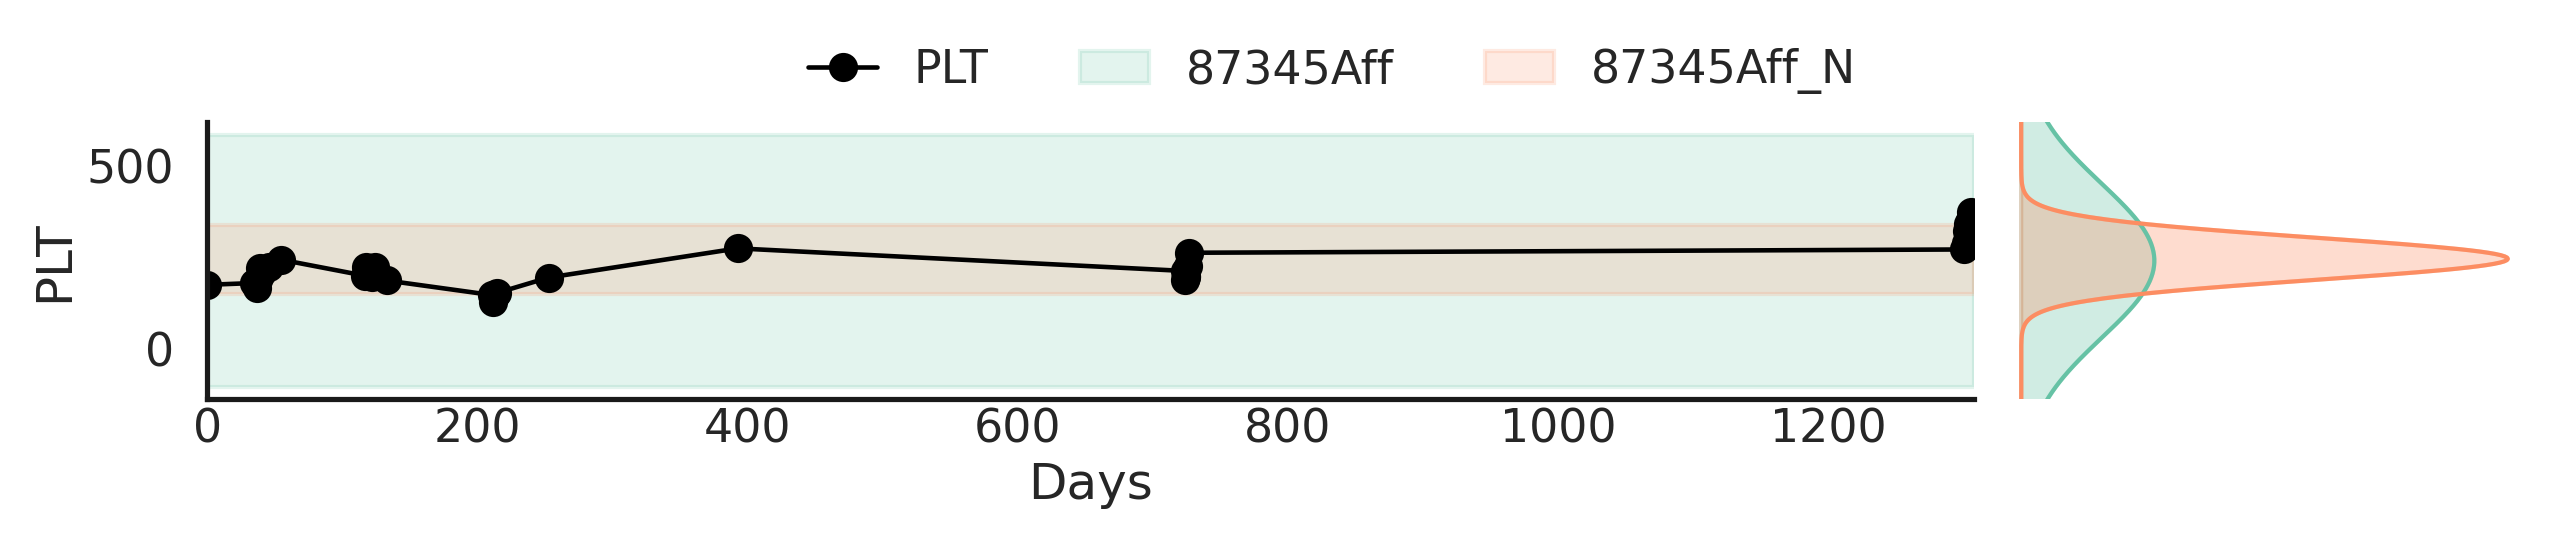

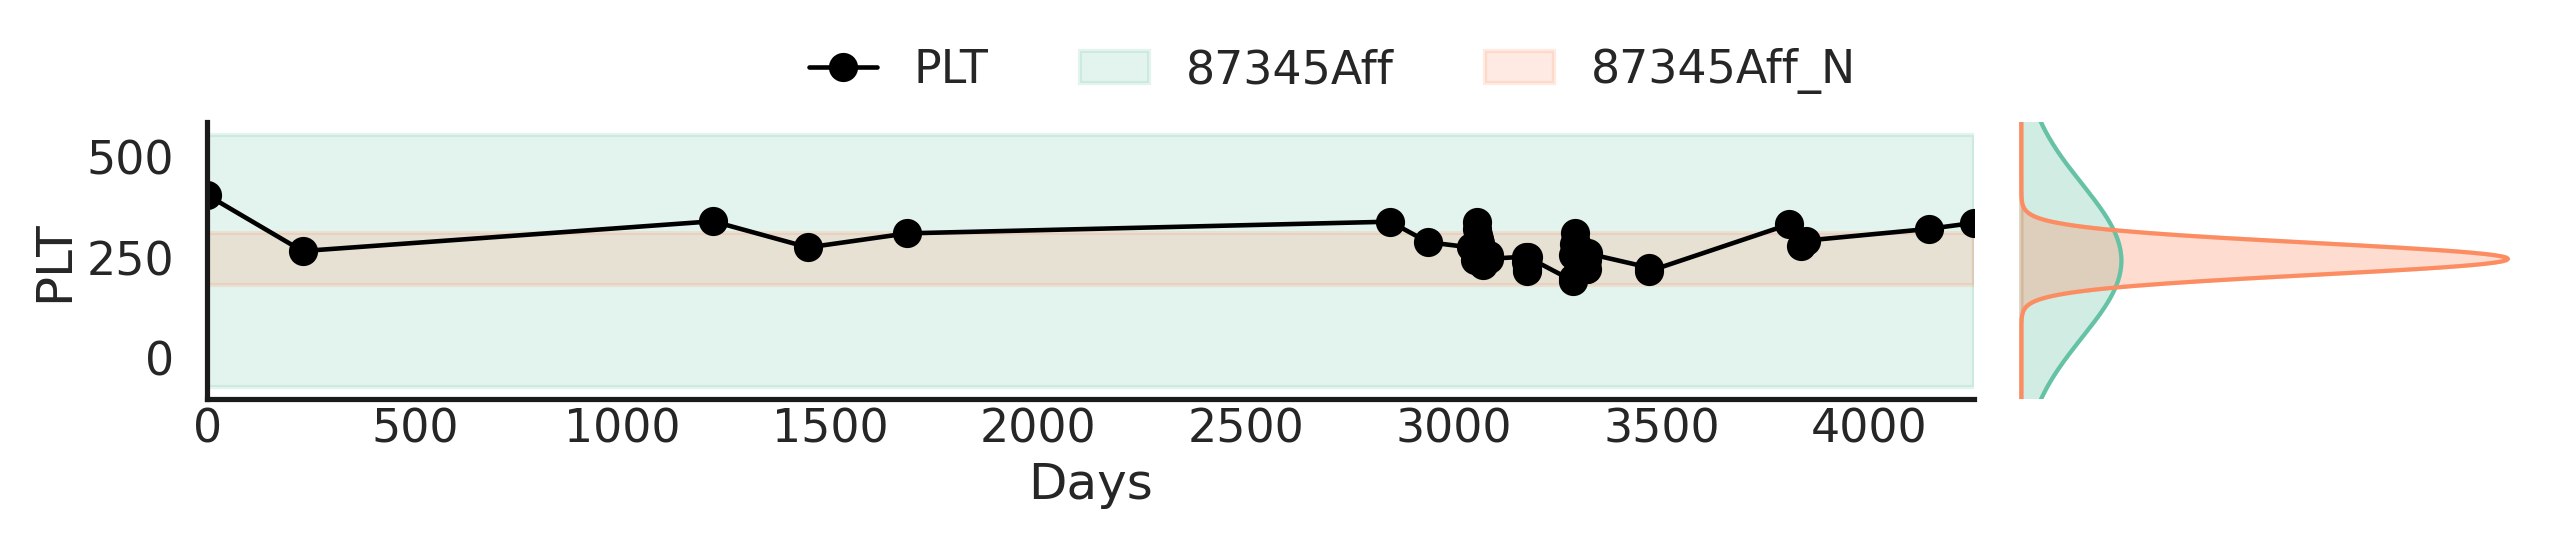

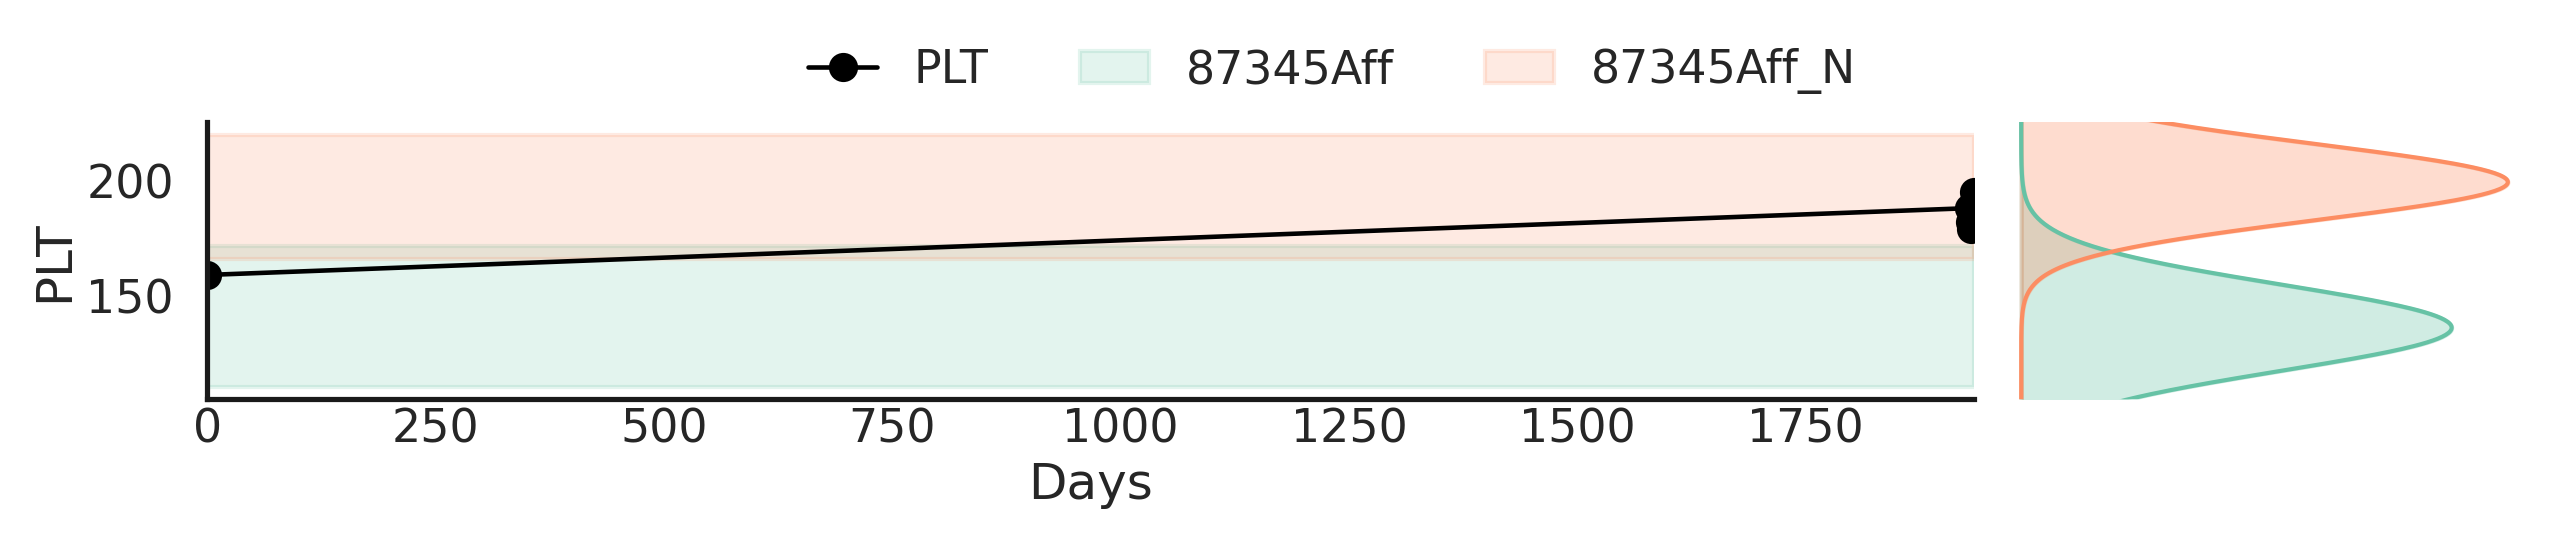

In [ ]:
run_ids = ['87345aff'] #332f2a3d'] #, 'b84f7b9e'] #, 'db1efe13']
results = predict_intervals(seqs, run_ids, LOG_DIR, device, add_baselines=False)
results.replace('87345aff', 'NORMA_Abnormal')
results.replace('87345aff_N', 'NORMA_Normal')
display(results) 


for (code, pid), group in results.groupby(['Code', 'PID']):
    pid = int(pid)
    plot_sequence_and_intervals(code, seqs[code].query('subject_id == @pid'), group)
  

In [70]:
pid

'19277306'

In [72]:
seqs[code].query('subject_id == 19277306')

,source,subject_id,sex,test_name,time_delta,numeric_value
31811082,mimiciv,19277306,0,TBIL,0.00000,0.5
31811083,mimiciv,19277306,0,TBIL,192.71527,0.5
31811084,mimiciv,19277306,0,TBIL,367.76390,0.8
31811085,mimiciv,19277306,0,TBIL,955.77920,1.0
31811086,mimiciv,19277306,0,TBIL,1144.73610,1.1
...,...,...,...,...,...,...
31811222,mimiciv,19277306,0,TBIL,3351.87230,0.4
31811223,mimiciv,19277306,0,TBIL,3362.72920,0.5
31811224,mimiciv,19277306,0,TBIL,3369.73120,0.4
31811225,mimiciv,19277306,0,TBIL,3376.71530,0.5
